# PINN for a 3D compressible Neo-Hookean solid

This PINN identifies Young's modulus and Poisson's ratio and displacement on the full reference cuboid:

$$
\Omega_0=[-5,5]\times[-5,5]\times[-0.5,0.5]\;\mathrm{mm}^3,
\qquad E_{\mathrm{true}}=0.005\;\mathrm{MPa},\quad \nu_{\mathrm{true}}=0.4.
$$

The four lateral faces carry an outward nominal traction of magnitude $q=0.001\;\mathrm{MPa}$. The top and bottom faces are traction-free. The body force is zero. Displacement observations select the reference position and provide information for material identification.

The compressible Neo-Hookean model is

$$
W(\mathbf{F})=\frac{\mu}{2}\left(\operatorname{tr}(\mathbf{F}^{\mathsf{T}}\mathbf{F})-3\right)
-\mu\ln J+\frac{\lambda}{2}(\ln J)^2,
\qquad J=\det\mathbf{F},
$$

$$
\mu=\frac{E}{2(1+\nu)},\qquad
\lambda=\frac{E\nu}{(1+\nu)(1-2\nu)},\qquad
\mathbf{P}=\mu(\mathbf{F}-\mathbf{F}^{-\mathsf{T}})+\lambda\ln J\,\mathbf{F}^{-\mathsf{T}}.
$$

Reference displacements are generated analytically.

Reference: Ferrón-Vivó et al., *Physics-Informed Neural Networks (PINNs) for solving the forward and inverse problems of prostate biomechanics*


## 1. Imports


In [39]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)


Device: cpu


## 2. Settings

 Material identification uses direct trainable scalars $\widehat{E}_\theta$ and $\nu_\theta$. The physical modulus is $E_\theta=E_{\mathrm{ref}}\widehat{E}_\theta$, a conversion by a fixed reference scale. `DATA_MODE` selects exact observations or fixed Gaussian noise. `VALIDATION_MODE` selects `"data"` or `"data_pde"`.

The nondimensionalization is as follows: $L_{\mathrm{ref}}=\operatorname{diam}\Omega_0$, $U_{\mathrm{ref}}=\max_{\partial\Omega_0}\|\mathbf{u}_{\mathrm{exact}}\|$, and $E_{\mathrm{ref}}=0.005\;\mathrm{MPa}$. Here the whole exterior boundary is used for the fixed displacement scale because there is no Dirichlet boundary. All reference scales are fixed before training.

$$
\widehat{\mathbf{X}}=\frac{\mathbf{X}}{L_{\mathrm{ref}}},\qquad
\widehat{\mathbf{u}}=\frac{\mathbf{u}}{U_{\mathrm{ref}}},\qquad
\widehat{\mathbf{P}}=\frac{\mathbf{P}}{E_{\mathrm{ref}}},\qquad
\widehat{\mathbf{t}}=\frac{\mathbf{t}}{E_{\mathrm{ref}}}.
$$

$$
\alpha=\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}},\qquad
\mathbf{F}=\mathbf{I}+\alpha\nabla_{\widehat{\mathbf{X}}}\widehat{\mathbf{u}},\qquad
\widehat{\mathbf{B}}=\frac{L_{\mathrm{ref}}}{E_{\mathrm{ref}}}\mathbf{B}=\mathbf{0}.
$$

All residuals are dimensionless. `WEIGHT_DATA`, `WEIGHT_NBC` and `WEIGHT_PDE` are equal to 1.

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DATA_MODE = "noisy"  # "exact" or "noisy"
NOISE_RELATIVE_STD = 0.02  
assert DATA_MODE in {"exact", "noisy"}
VALIDATION_MODE = "data_pde"  # "data_pde": data + PDE; "data": just data
assert VALIDATION_MODE in {"data", "data_pde"}

SIDE_X, SIDE_Y, SIDE_Z = 10.0, 10.0, 1.0
HALF = np.array([SIDE_X, SIDE_Y, SIDE_Z]) / 2.0
E_TRUE, POISSON_TRUE, TRACTION = 0.005, 0.4, 0.001
E_REF = 0.009 
L_REF = np.linalg.norm(2.0 * HALF)
N_DATA, N_VALIDATION, N_TEST = 75, 30, 150
PDE_TRAIN_SHAPE = (10, 10, 2)
PDE_VALIDATION_SHAPE = (12, 12, 3)
PDE_TEST_SHAPE = (13, 13, 3)
N_PDE, N_PDE_VALIDATION, N_PDE_TEST = [int(np.prod(s)) for s in [PDE_TRAIN_SHAPE, PDE_VALIDATION_SHAPE, PDE_TEST_SHAPE]]
STYLE = "ours"
POISSON_INITIAL = 0.01
E_INITIAL = 0.010/E_REF
EPOCHS, LBFGS_EPOCHS = 5000, 100
ADAM_EPOCHS = EPOCHS-LBFGS_EPOCHS
LR = 0.001
PRINT_EVERY = 500
PDE_BATCH_SIZE = 32

WEIGHT_DATA, WEIGHT_NBC, WEIGHT_PDE = 1.0, 1.0, 1.0


## 3. Exact solution and Neumann boundary conditions

The reference solution corresponds to the fixed material parameters
$E_{\mathrm{true}}=0.005\ \mathrm{MPa}$,
$\nu_{\mathrm{true}}=0.4$ and the prescribed nominal traction
$q=0.001\ \mathrm{MPa}$.

First consider the positive octant $[0,5]\times[0,5]\times[0,0.5]$.
Symmetry gives zero normal displacement on $X=0$, $Y=0$ and $Z=0$.
The outer $X$ and $Y$ faces carry traction $q$; the outer $Z$ face is free.

The resulting displacement field is approximately

$$
\mathbf{u}_{\mathrm{exact}}(X,Y,Z)=
\begin{bmatrix}
0.148492561\,X\\
0.148492561\,Y\\
-0.177881196\,Z
\end{bmatrix}.
$$

Coordinates and displacements are expressed in mm. The deformation gradient
and its determinant are constant:

$$
\mathbf{F}\approx\operatorname{diag}(1.148492561,\ 1.148492561,\ 0.822118804),
\qquad
J\approx1.084403610.
$$

For the prescribed material parameters, the first Piola–Kirchhoff stress is,
up to numerical precision,

$$
\mathbf{P}=
\begin{bmatrix}
0.001&0&0\\
0&0.001&0\\
0&0&0
\end{bmatrix}
\ \mathrm{MPa}.
$$

Since the stress is constant, $\operatorname{Div}_{\mathbf{X}}\mathbf{P}=\mathbf{0}$.

Reflection across the three symmetry planes extends this solution to the
full cuboid $[-5,5]\times[-5,5]\times[-0.5,0.5]$ using the same displacement
formula. On $X=\pm5$ and $Y=\pm5$, the traction is
$\mathbf{P}\mathbf{N}=q\mathbf{N}$; on $Z=\pm0.5$ it is zero.
The symmetry planes are internal planes of the full cuboid.

Displacement scale
is defined using the exact displacement on the entire exterior boundary.
Its maximum norm is attained at a corner (also if the displacement formula wasn't available, then we can use maximum norm from the observations):

$$
U_{\mathrm{ref}}
=\sqrt{2(5\cdot0.148492561)^2+(0.5\cdot0.177881196)^2}
\approx1.053761\ \mathrm{mm}.
$$

The fixed displacement formula is used directly to generate reference data.

In [24]:
def lame_parameters(E_pred, nu):
    return E_pred / (2.0 * (1.0 + nu)), E_pred * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))



S_TRUE = 1.1484925608277146
T_TRUE = 0.8221188041962557
U_REF = np.linalg.norm(HALF*np.array([S_TRUE-1,S_TRUE-1,T_TRUE-1]))
ALPHA = U_REF/L_REF
STRETCH_TRUE = torch.tensor([S_TRUE, S_TRUE, T_TRUE], device=DEVICE)


def exact_displacement(x_ref):
    return x_ref * (STRETCH_TRUE - 1.0)


MU_TRUE, LAME_LAMBDA_TRUE = lame_parameters(E_TRUE, POISSON_TRUE)
J_TRUE = S_TRUE*S_TRUE*T_TRUE
P_TRUE = np.diag([MU_TRUE * (S_TRUE - 1.0/S_TRUE) + LAME_LAMBDA_TRUE*np.log(J_TRUE)/S_TRUE,
                  MU_TRUE * (S_TRUE - 1.0/S_TRUE) + LAME_LAMBDA_TRUE*np.log(J_TRUE)/S_TRUE,
                  MU_TRUE * (T_TRUE - 1.0/T_TRUE) + LAME_LAMBDA_TRUE*np.log(J_TRUE)/T_TRUE])
assert np.allclose(P_TRUE, np.diag([TRACTION, TRACTION, 0.0]), rtol=0, atol=1e-14)
print(f"s={S_TRUE:.10f}, t={T_TRUE:.10f}, J={J_TRUE:.10f}")
print("Analytic nominal stress [MPa]:\n", P_TRUE)


s=1.1484925608, t=0.8221188042, J=1.0844036103
Analytic nominal stress [MPa]:
 [[1.00000000e-03 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 7.58941521e-19]]


## 4. Neural network and trainable material parameters

The network maps three dimensionless coordinates to three dimensionless displacement components. Two scalar parameters identify the material:

$$
\widehat{E}_\theta=\texttt{nn.Parameter}(\widehat{E}_{\mathrm{initial}}),\qquad
\nu_\theta=\texttt{nn.Parameter}(\nu_{\mathrm{initial}}).
$$

The Lamé parameters are calculated directly from their current values:

$$
\widehat{\mu}_\theta=\frac{\widehat{E}_\theta}{2(1+\nu_\theta)},\qquad
\widehat{\lambda}_\theta=\frac{\widehat{E}_\theta\nu_\theta}{(1+\nu_\theta)(1-2\nu_\theta)}.
$$

This variant uses 3 hidden layers with 9 neurons each and tanh activations. Adam uses PDE mini-batches, followed by 100 L-BFGS steps.


In [25]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 9),
            nn.Tanh(),
            nn.Linear(9, 9),
            nn.Tanh(),
            nn.Linear(9, 9),
            nn.Tanh(),
            nn.Linear(9, 3),
        )
        self.E = nn.Parameter(torch.tensor(E_INITIAL))
        self.nu = nn.Parameter(torch.tensor(POISSON_INITIAL))

    def forward(self, xyz):
        return self.net(xyz)

    def young_modulus(self):
        return self.E

    def poisson_ratio(self):
        return self.nu

    def material_parameters(self):
        E, nu = self.young_modulus(), self.poisson_ratio()
        shear_mu = E / (2.0 * (1.0 + nu))
        lame_lambda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        return E, nu, lame_lambda, shear_mu

    def material(self):
        return E_REF*self.E, self.nu


model = InversePINN().to(DEVICE)
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")


Trainable parameters: 248


## 5. PDE train, validation, and test points

All three sets are complete uniform interior Cartesian grids. `PDE_TRAIN_SHAPE`, `PDE_VALIDATION_SHAPE` and `PDE_TEST_SHAPE` set their sizes. Different within-cell shifts keep their coordinates mutually disjoint, including when the grid shapes are identical.


In [26]:
def sample_faces(counts, generator):
    coords, normals = [], []
    for face, count in enumerate(counts):
        axis, sign = face // 2, (-1.0 if face % 2 == 0 else 1.0)
        x = generator.uniform(-HALF, HALF, size=(count, 3))
        x[:, axis] = sign * HALF[axis]
        n = np.zeros_like(x)
        n[:, axis] = sign
        coords.append(x)
        normals.append(n)
    return np.concatenate(coords), np.concatenate(normals)


def grid(shape, shift=0.5):
    axes = [-h+(np.arange(n)+shift)*2*h/n for h,n in zip(HALF,shape)]
    return np.stack(np.meshgrid(*axes,indexing="ij"),axis=-1).reshape(-1,3)


def point_keys(x):
    return {tuple(row) for row in np.round(x,10)}


def check_disjoint(*pools):
    used = set()
    for pool in pools:
        keys = point_keys(pool)
        assert len(keys) == len(pool), "Duplicite points"
        assert used.isdisjoint(keys), "overlap between pools"
        used.update(keys)


x_pde_ref = grid(PDE_TRAIN_SHAPE,shift=0.5)
x_valid_pde_ref = grid(PDE_VALIDATION_SHAPE,shift=np.sqrt(2)-1)
x_test_ref = grid(PDE_TEST_SHAPE,shift=np.sqrt(3)-1)

def tensor(array):
    return torch.as_tensor(array,device=DEVICE).clone()

x_pde, x_valid_pde, x_test = [tensor(x/L_REF) for x in [x_pde_ref,x_valid_pde_ref,x_test_ref]]
pde_batch_generator = torch.Generator().manual_seed(SEED+1)
pde_train_loader = DataLoader(TensorDataset(x_pde),batch_size=PDE_BATCH_SIZE,
                             shuffle=True,generator=pde_batch_generator)
print("PDE train/validation/test:",len(x_pde),len(x_valid_pde),len(x_test))


PDE train/validation/test: 200 432 507


## 6. Neumann boundary points and supervised data

There are traction points on the four lateral faces and traction-free points on the top and bottom Displacement observations lie on the exterior boundary and sample faces in proportion to their areas.

Training, validation and test observations have separate fixed ordered pools of 500, 200 and 500 points. The active counts are controlled by `N_DATA`, `N_VALIDATION`, `N_TEST`.

`DATA_MODE = "exact"` gives clean analytic observations. In `"noisy"` mode the fixed training pool receives Gaussian noise. Validation and test reference values remain exact.


In [27]:

rng_data = np.random.default_rng(SEED)
face_area = np.array([SIDE_Y*SIDE_Z]*2+[SIDE_X*SIDE_Z]*2+[SIDE_X*SIDE_Y]*2)
face_ids = rng_data.choice(6,size=1200,p=face_area/face_area.sum())
data_pool = rng_data.uniform(-HALF,HALF,size=(1200,3))
axis_ids = face_ids//2
signs = np.where(face_ids%2==0,-1.0,1.0)
data_pool[np.arange(1200),axis_ids] = signs*HALF[axis_ids]
data_train_pool, data_valid_pool, data_test_pool = data_pool[:500],data_pool[500:700],data_pool[700:]


x_bc_ref, normal_bc = sample_faces([10,10,10,10,5,5],np.random.default_rng(SEED+1))
traction_bc = normal_bc*TRACTION
traction_bc[:,2] = 0.0

check_disjoint(data_train_pool,data_valid_pool,data_test_pool,x_bc_ref,
               x_pde_ref,x_valid_pde_ref,x_test_ref)


assert 1 <= N_DATA <= 500 and 1 <= N_VALIDATION <= 200 and 1 <= N_TEST <= 500, "Data: train 1–500, validace 1–200, test 1–500"
x_data_ref = data_train_pool[:N_DATA]
x_valid_ref = data_valid_pool[:N_VALIDATION]
x_test_boundary_ref = data_test_pool[:N_TEST]


x_data, x_valid, x_test_boundary = [tensor(x/L_REF) for x in [x_data_ref,x_valid_ref,x_test_boundary_ref]]
x_bc, n_bc, t_bc_hat = tensor(x_bc_ref/L_REF),tensor(normal_bc),tensor(traction_bc/E_REF)
u_pool_hat = exact_displacement(tensor(data_train_pool))/U_REF
if DATA_MODE == "noisy":
    component_scales = np.abs(HALF*np.array([S_TRUE-1,S_TRUE-1,T_TRUE-1]))
    noise = np.random.default_rng(SEED+3).normal(size=(500,3))
    u_pool_hat += tensor(noise)*(NOISE_RELATIVE_STD*component_scales/U_REF)
u_data_hat = u_pool_hat[:N_DATA]
u_valid_hat = exact_displacement(tensor(x_valid_ref))/U_REF
u_test_boundary_hat = exact_displacement(tensor(x_test_boundary_ref))/U_REF
print("Data train/validation/test:",N_DATA,N_VALIDATION,N_TEST)
print("PDE train/validation/test:",N_PDE,N_PDE_VALIDATION,N_PDE_TEST)


Data train/validation/test: 15 10 300
PDE train/validation/test: 200 432 507


## 7. Physics residual and inverse training

Automatic differentiation computes the scaled stress and equilibrium residual:

$$
\widehat{\mathbf{P}}_\theta=
\widehat{\mu}_\theta(\mathbf{F}_\theta-\mathbf{F}_\theta^{-\mathsf{T}})
+\widehat{\lambda}_\theta\ln J_\theta\,\mathbf{F}_\theta^{-\mathsf{T}},\qquad
\widehat{\mathbf{r}}_\theta=
\operatorname{Div}_{\widehat{\mathbf{X}}}\widehat{\mathbf{P}}_\theta.
$$

$$
\mathcal{L}_{\mathrm{train}}=
\omega_{\mathrm{PDE}}\mathcal{L}_{\mathrm{PDE}}+
\omega_{\mathrm{NBC}}\mathcal{L}_{\mathrm{NBC}}+
\omega_{\mathrm{data}}\mathcal{L}_{\mathrm{data}}.
$$

Each loss is the mean squared residual.



In [28]:
def displacement_and_stress(x_hat, net=model, need_residual=False, residual_create_graph=True):
    x = x_hat.detach().clone().requires_grad_(True)
    u_hat = net(x)
    grad_rows = [torch.autograd.grad(u_hat[:, i].sum(), x, create_graph=True,
                                    retain_graph=True)[0] for i in range(3)]
    grad_u = torch.stack(grad_rows, dim=1)
    F = torch.eye(3, device=DEVICE).unsqueeze(0) + ALPHA*grad_u
    J = torch.linalg.det(F)
    inv_F_T = torch.linalg.inv(F).transpose(-1, -2)
    _, _, lam_hat, mu_hat = net.material_parameters()
    P_hat = mu_hat*(F-inv_F_T) + lam_hat*torch.log(torch.clamp(J, min=1e-8))[:,None,None]*inv_F_T
    if not need_residual:
        return u_hat, P_hat, J
    div_components = []
    for i in range(3):
        div_i = torch.zeros_like(x[:,0])
        for j in range(3):
            grad_Pij = torch.autograd.grad(P_hat[:,i,j].sum(), x,
                                           create_graph=residual_create_graph, retain_graph=True)[0]
            div_i = div_i + grad_Pij[:,j]
        div_components.append(div_i)
    return u_hat, P_hat, J, torch.stack(div_components,dim=1)


loss_history, pde_loss_history, bc_loss_history, data_loss_history = [], [], [], []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
E_history, poisson_history = [], []
best_validation_loss = float("inf")
best_epoch, best_model_state = None, None


def print_training_losses(epoch, values, optimizer_name):
    if (epoch+1) % PRINT_EVERY != 0:
        return
    total, pde, nbc, data = values
    message = (f"{optimizer_name} | epoch {epoch+1:5d} | total={total:.6e} | "
               f"data={data:.6e} | NBC={nbc:.6e} | "
               f"PDE={pde:.6e}")
    message += f" | E={E_history[-1]:.7f} MPa | nu={poisson_history[-1]:.5f}"
    print(message)


def compute_training_losses(xyz_pde):
    _, _, _, residual = displacement_and_stress(xyz_pde,need_residual=True)
    loss_pde = torch.mean(residual**2)
    _, P_bc, _ = displacement_and_stress(x_bc)
    loss_bc = torch.mean((torch.einsum('nij,nj->ni',P_bc,n_bc)-t_bc_hat)**2)
    loss_data = torch.mean((model(x_data)-u_data_hat)**2)
    loss = (WEIGHT_PDE*loss_pde + WEIGHT_NBC*loss_bc +
            WEIGHT_DATA*loss_data)
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    with torch.no_grad():
        loss_data = torch.mean((model(x_valid)-u_valid_hat)**2)
    loss_pde = loss_data.new_zeros(())
    if VALIDATION_MODE == "data_pde":
        _, _, _, residual = displacement_and_stress(x_valid_pde,need_residual=True,residual_create_graph=False)
        loss_pde = torch.mean(residual.detach()**2)
    return WEIGHT_PDE*loss_pde+WEIGHT_DATA*loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_epoch, best_model_state
    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    value = loss.item()
    validation_loss_history.append(value)
    validation_pde_loss_history.append(loss_pde.item())
    validation_data_loss_history.append(loss_data.item())
    E_pred, nu = model.material()
    E_history.append(E_pred.detach().item())
    poisson_history.append(nu.detach().item())
    if best_model_state is None or value < best_validation_loss:
        best_validation_loss, best_epoch = value, epoch
        best_model_state = copy.deepcopy(model.state_dict())
    model.train()


for epoch in range(ADAM_EPOCHS):
    epoch_sums, samples = np.zeros(4), 0
    for (xyz_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(xyz_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        batch_size = len(xyz_pde_batch)
        epoch_sums += np.array([v.detach().item() for v in losses])*batch_size
        samples += batch_size
    values = epoch_sums/samples
    for series,value in zip([loss_history,pde_loss_history,bc_loss_history,data_loss_history],values):
        series.append(value)
    update_checkpoint(epoch)
    print_training_losses(epoch, values, "Adam")


if LBFGS_EPOCHS > 0:
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(),lr=0.1,max_iter=20,
                                     history_size=50,line_search_fn="strong_wolfe")
    for lbfgs_epoch in range(LBFGS_EPOCHS):
        epoch = ADAM_EPOCHS+lbfgs_epoch
        def closure():
            optimizer_lbfgs.zero_grad(set_to_none=True)
            loss, _, _, _ = compute_training_losses(x_pde)
            loss.backward()
            return loss
        optimizer_lbfgs.step(closure)
        losses = compute_training_losses(x_pde)
        for series,value in zip([loss_history,pde_loss_history,bc_loss_history,data_loss_history],losses):
            series.append(value.detach().item())
        update_checkpoint(epoch)
        print_training_losses(epoch, [value.detach().item() for value in losses], "L-BFGS")


model.load_state_dict(best_model_state)
model.eval()
print(f"Best epoch: {best_epoch}; validation loss: {best_validation_loss:.6e}")


Adam | epoch   500 | total=1.059825e-04 | data=7.521744e-05 | NBC=3.865784e-06 | PDE=2.689923e-05 | E=0.0050520 MPa | nu=0.37631
Adam | epoch  1000 | total=6.767649e-05 | data=6.091229e-05 | NBC=2.648294e-06 | PDE=4.115916e-06 | E=0.0049767 MPa | nu=0.39690
Adam | epoch  1500 | total=6.182896e-05 | data=5.727832e-05 | NBC=3.020971e-06 | PDE=1.529664e-06 | E=0.0049447 MPa | nu=0.40071
Adam | epoch  2000 | total=5.905395e-05 | data=5.459842e-05 | NBC=3.215779e-06 | PDE=1.239756e-06 | E=0.0049385 MPa | nu=0.40187
Adam | epoch  2500 | total=5.715795e-05 | data=5.248125e-05 | NBC=3.371183e-06 | PDE=1.305519e-06 | E=0.0049311 MPa | nu=0.40252
Adam | epoch  3000 | total=5.603987e-05 | data=5.114965e-05 | NBC=3.545085e-06 | PDE=1.345129e-06 | E=0.0049291 MPa | nu=0.40301
Adam | epoch  3500 | total=5.499208e-05 | data=4.967775e-05 | NBC=3.747194e-06 | PDE=1.567134e-06 | E=0.0049290 MPa | nu=0.40398
Adam | epoch  4000 | total=5.316222e-05 | data=4.731245e-05 | NBC=3.948906e-06 | PDE=1.900867e-06

## 8. Final test metrics

The best validation checkpoint is evaluated on the boundary observations and interior test grid. Predicted displacements are converted to mm and the learned modulus to MPa.

In [29]:
model.load_state_dict(best_model_state)
with torch.enable_grad():
    u_hat, _, J, residual = displacement_and_stress(x_test,need_residual=True,residual_create_graph=False)
u_pred = U_REF*u_hat.detach()
u_true = exact_displacement(tensor(x_test_ref))
relative_l2 = (torch.linalg.norm(u_pred-u_true)/torch.linalg.norm(u_true)).item()
with torch.no_grad():
    boundary_rmse = U_REF*torch.sqrt(torch.mean((model(x_test_boundary)-u_test_boundary_hat)**2))
E_pred, nu = model.material()
print(f"Identified E={E_pred.item():.7f} MPa, nu={nu.item():.6f}")
print(f"True E={E_TRUE:.7f} MPa, nu={POISSON_TRUE}")
print(f"Test relative L2(u)={relative_l2:.3e}; boundary RMSE={boundary_rmse.item():.3e} mm")
print(f"Test PDE RMSE={torch.sqrt(torch.mean(residual.detach()**2)).item():.3e}; min J={J.detach().min().item():.6f}")


Identified E=0.0049788 MPa, nu=0.397546
True E=0.0050000 MPa, nu=0.4
Test relative L2(u)=2.751e-02; boundary RMSE=1.213e-02 mm
Test PDE RMSE=2.266e-03; min J=1.082831


## 9. Plots

In [40]:
def plot_data_split():
    fig = plt.figure(figsize=(12,5),constrained_layout=True)
    ax = fig.add_subplot(121,projection="3d")
    for x,color,label in [(x_pde_ref,"tab:blue","train"),(x_valid_pde_ref,"tab:green","validation"),(x_test_ref,"tab:orange","test")]:
        ax.scatter(*x.T,s=5,alpha=.4,color=color,label=f"{label} ({len(x)})")
    ax.set(xlabel="X [mm]",ylabel="Y [mm]",zlabel="Z [mm]",title="PDE collocation points")
    ax.legend(fontsize=8)
    ax = fig.add_subplot(122,projection="3d")
    for x,color,label in [(x_data_ref,"tab:blue","data train"),(x_valid_ref,"tab:green","data validation"),(x_test_boundary_ref,"tab:orange","data test"),(x_bc_ref,"black","Neumann")]:
        ax.scatter(*x.T,s=10,alpha=.65,color=color,label=f"{label} ({len(x)})")
    ax.set(xlabel="X [mm]",ylabel="Y [mm]",zlabel="Z [mm]",title="Boundary and data")
    ax.legend(fontsize=8)
    fig.savefig(OUTPUT_DIR/f"cuboid_{STYLE}_points.pdf",bbox_inches="tight")
    plt.show()


def plot_losses():
    fig,axes = plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
    for series,label in [(loss_history,"total"),(np.array(pde_loss_history)*WEIGHT_PDE,"weighted PDE"),(np.array(bc_loss_history)*WEIGHT_NBC,"weighted Neumann"),(np.array(data_loss_history)*WEIGHT_DATA,"weighted data")]:
        axes[0].plot(series,label=label)
    axes[1].plot(validation_loss_history,label=f"validation ({VALIDATION_MODE})")
    axes[1].plot(np.array(validation_data_loss_history)*WEIGHT_DATA,label="weighted data")
    if VALIDATION_MODE == "data_pde":
        axes[1].plot(np.array(validation_pde_loss_history)*WEIGHT_PDE,label="weighted PDE")
    for ax,title in zip(axes,["Training losses","Validation losses"]):
        ax.set_yscale("log")
        ax.axvline(best_epoch,color="tab:green",ls="--",label="best epoch")
        if LBFGS_EPOCHS > 0:
            ax.axvline(ADAM_EPOCHS,color="black",ls=":",label="switch to L-BFGS")
        ax.set(xlabel="epoch",ylabel="weighted loss",title=title)
        ax.grid(alpha=.25,which="both")
        ax.legend(fontsize=8)
    fig.savefig(OUTPUT_DIR/f"cuboid_{STYLE}_losses.pdf",bbox_inches="tight")
    plt.show()



def plot_material_parameters():
    fig,axes = plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
    for ax,series,true_value,name,unit in [(axes[0],E_history,E_TRUE,"E","MPa"),(axes[1],poisson_history,POISSON_TRUE,"nu","dimensionless")]:
        ax.plot(series,label=f"identified {name}")
        ax.axhline(true_value,color="black",ls="--",label="true value")
        ax.scatter([best_epoch],[series[best_epoch]],color="tab:green",zorder=3,label="best epoch")
        if LBFGS_EPOCHS > 0:
            ax.axvline(ADAM_EPOCHS,color="gray",ls=":",label="switch to L-BFGS")
        ax.set(xlabel="epoch",ylabel=f"{name} [{unit}]",title=f"Identification of {name}")
        ax.grid(alpha=.25)
        ax.legend(fontsize=8)
    fig.savefig(OUTPUT_DIR/f"cuboid_{STYLE}_parameters.pdf",bbox_inches="tight")
    plt.show()

from matplotlib.lines import Line2D

def make_reference_faces(half_lengths, n_side=21):
    faces = []
    for normal_axis in range(3):
        tangential_axes = [j for j in range(3) if j != normal_axis]
        a,b = tangential_axes
        A,B = np.meshgrid(np.linspace(-half_lengths[a],half_lengths[a],n_side),
                          np.linspace(-half_lengths[b],half_lengths[b],n_side),indexing="ij")
        for sign in (-1.0,1.0):
            face = np.zeros((n_side,n_side,3))
            face[:,:,normal_axis] = sign*half_lengths[normal_axis]
            face[:,:,a],face[:,:,b] = A,B
            faces.append(face)
    return faces


def plot_geometry_comparison(reference_faces, exact_faces, pinn_faces):
    all_points = np.concatenate([f.reshape(-1,3) for fs in [reference_faces,exact_faces,pinn_faces] for f in fs])
    lo,hi = all_points.min(axis=0),all_points.max(axis=0)
    padding = .04*np.maximum(hi-lo,1e-6)
    lo,hi = lo-padding,hi+padding
    fig = plt.figure(figsize=(14,9),constrained_layout=True)
    axes = [fig.add_subplot(2,2,i+1,projection="3d") for i in range(4)]
    colors = ["gray","tab:blue","tab:orange"]
    titles = ["Reference cuboid","Analytic deformation","PINN deformation","Overlay"]
    for ax,faces,color in zip(axes[:3],[reference_faces,exact_faces,pinn_faces],colors):
        for face in faces:
            ax.plot_surface(face[:,:,0],face[:,:,1],face[:,:,2],color=color,alpha=.45,
                            linewidth=0,shade=True)
            ax.plot_wireframe(face[:,:,0],face[:,:,1],face[:,:,2],color=color,
                              rstride=5,cstride=5,linewidth=.45,alpha=.7)
    for faces,color in zip([reference_faces,exact_faces,pinn_faces],colors):
        for face in faces:
            axes[3].plot_wireframe(face[:,:,0],face[:,:,1],face[:,:,2],color=color,
                                   rstride=5,cstride=5,linewidth=.55,alpha=.7)
    axes[3].legend(handles=[Line2D([0],[0],color=c,label=l) for c,l in
                          zip(colors,["reference","analytic deformation","PINN deformation"])],fontsize=8)
    for ax,title in zip(axes,titles):
        ax.set(xlim=(lo[0],hi[0]),ylim=(lo[1],hi[1]),zlim=(lo[2],hi[2]),
               xlabel="X / x [mm]",ylabel="Y / y [mm]",zlabel="Z / z [mm]",title=title)
        ax.set_box_aspect(hi-lo)
        ax.set_zticks([lo[2],hi[2]])
        ax.set_zticklabels([f"{lo[2]:.2f}",f"{hi[2]:.2f}"],fontsize=8)
        ax.xaxis.labelpad = 12
        ax.yaxis.labelpad = 12
        ax.zaxis.labelpad = 14
        ax.view_init(elev=23,azim=-55)
    plt.show()
    return fig


def plot_geometry():
    reference_faces = make_reference_faces(HALF)
    exact_faces, pinn_faces = [], []
    model.load_state_dict(best_model_state)
    for face in reference_faces:
        X_ref = face.reshape(-1,3)
        exact_faces.append((X_ref*np.array([S_TRUE,S_TRUE,T_TRUE])).reshape(face.shape))
        with torch.no_grad():
            u_pred = U_REF*model(tensor(X_ref/L_REF)).cpu().numpy()
        pinn_faces.append((X_ref+u_pred).reshape(face.shape))
    fig = plot_geometry_comparison(reference_faces,exact_faces,pinn_faces)

    fig.savefig(OUTPUT_DIR/f"cuboid_{STYLE}_deformation.pdf",bbox_inches="tight")


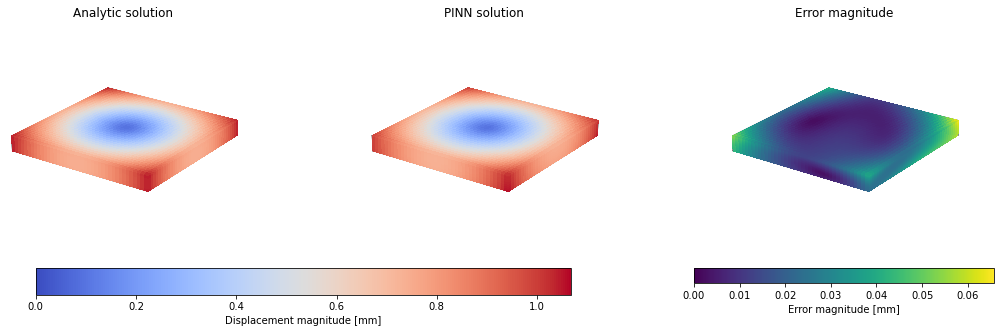

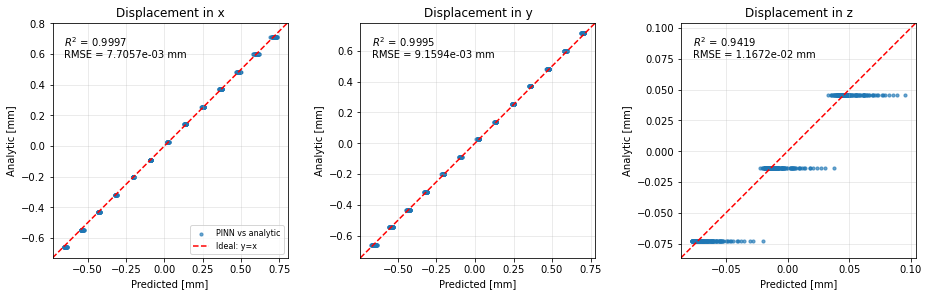

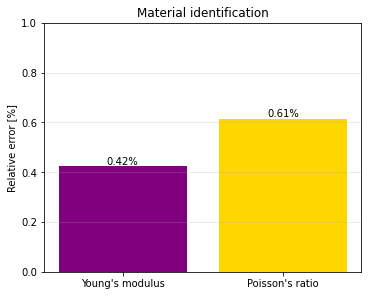

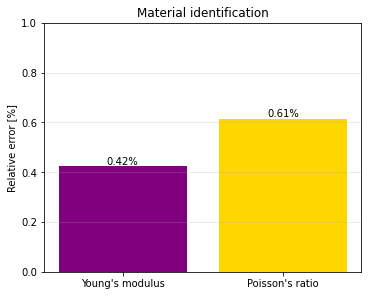

In [41]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def displacement_values(x_ref):
    model.eval()
    with torch.no_grad():
        u_true = exact_displacement(tensor(x_ref)).cpu().numpy()
        if STYLE == "ours":
            u_pred = U_REF * model(tensor(x_ref / L_REF)).cpu().numpy()
        else:
            u_pred = model(tensor(x_ref)).cpu().numpy()
    return u_true, u_pred

def draw_surface_field(ax, faces, values, cmap, norm):
    for face, value in zip(faces, values):
        cell_value = (value[:-1, :-1] + value[1:, :-1] + value[:-1, 1:] + value[1:, 1:]) / 4
        ax.plot_surface(face[:, :, 0], face[:, :, 1], face[:, :, 2], facecolors=cmap(norm(cell_value)), rstride=1, cstride=1, shade=False, linewidth=0, antialiased=False, rasterized=True)
        for edge in (face[0], face[-1], face[:, 0], face[:, -1]):
            ax.plot(*edge.T, color="black", linewidth=0.5)
    ax.set(xlim=(-HALF[0], HALF[0]), ylim=(-HALF[1], HALF[1]), zlim=(-HALF[2], HALF[2]))
    ax.set_box_aspect(2 * HALF)
    ax.view_init(elev=23, azim=-55)
    ax.set_axis_off()

def plot_displacement_magnitudes(n_side=41):
    faces = make_reference_faces(HALF, n_side=n_side)
    fields = [[], [], []]
    for face in faces:
        u_true, u_pred = displacement_values(face.reshape(-1, 3))
        for values, displacement in zip(fields, (u_true, u_pred, u_pred - u_true)):
            values.append(np.linalg.norm(displacement, axis=1).reshape(face.shape[:2]))
    maximum = max(v.max() for values in fields[:2] for v in values)
    error_maximum = max(v.max() for v in fields[2])
    norm_u = Normalize(0, max(maximum, 1e-12))
    norm_error = Normalize(0, max(error_maximum, 1e-12))
    cmap_u = plt.get_cmap("coolwarm")
    cmap_error = plt.get_cmap("viridis")
    fig = plt.figure(figsize=(15, 4.5), constrained_layout=True)
    axes = [fig.add_subplot(1, 3, i + 1, projection="3d") for i in range(3)]
    titles = ["Analytic solution", "PINN solution", "Error magnitude"]
    for i, (ax, values, title) in enumerate(zip(axes, fields, titles)):
        draw_surface_field(ax, faces, values, cmap_u if i < 2 else cmap_error, norm_u if i < 2 else norm_error)
        ax.set_title(title)
    fig.colorbar(ScalarMappable(norm=norm_u, cmap=cmap_u), ax=axes[:2], orientation="horizontal", shrink=0.75, label="Displacement magnitude [mm]")
    fig.colorbar(ScalarMappable(norm=norm_error, cmap=cmap_error), ax=axes[2], orientation="horizontal", shrink=0.85, label="Error magnitude [mm]")
    fig.savefig(OUTPUT_DIR / f"cuboid_{STYLE}_magnitudes.pdf", bbox_inches="tight")
    plt.show()
    return fig

def plot_displacement_comparison():
    u_true, u_pred = displacement_values(x_test_ref)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    for i, ax in enumerate(axes):
        real = u_true[:, i]
        predicted = u_pred[:, i]
        rmse = np.sqrt(np.mean((real - predicted)**2))
        denominator = np.sum((real - real.mean())**2)
        r2 = 1 - np.sum((real - predicted)**2) / denominator if denominator > 0 else np.nan
        lo = min(real.min(), predicted.min())
        hi = max(real.max(), predicted.max())
        padding = 0.05 * max(hi - lo, 1e-6)
        lo, hi = lo - padding, hi + padding
        ax.scatter(predicted, real, s=10, alpha=0.65, label="PINN vs analytic")
        ax.plot([lo, hi], [lo, hi], "r--", label="Ideal: y=x")
        ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel="Predicted [mm]", ylabel="Analytic [mm]", title=f"Displacement in {'xyz'[i]}")
        ax.set_aspect("equal", adjustable="box")
        ax.text(0.05, 0.95, f"$R^2$ = {r2:.4f}\nRMSE = {rmse:.4e} mm", transform=ax.transAxes, va="top")
        ax.grid(alpha=0.3)
    axes[0].legend(loc="lower right", fontsize=8)
    fig.savefig(OUTPUT_DIR / f"cuboid_{STYLE}_displacement_comparison.pdf", bbox_inches="tight")
    plt.show()
    return fig

def plot_parameter_errors():
    E_pred, poisson_pred = model.material()
    errors = 100 * np.abs(np.array([E_pred.detach().cpu().item() / E_TRUE - 1, poisson_pred.detach().cpu().item() / POISSON_TRUE - 1]))
    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    bars = ax.bar(["Young's modulus", "Poisson's ratio"], errors, color=["purple", "gold"])
    for bar, value in zip(bars, errors):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.2f}%", ha="center", va="bottom")
    ax.set(ylabel="Relative error [%]", title="Material identification")
    ax.set_ylim(0, max(errors.max() * 1.25, 1))
    ax.grid(axis="y", alpha=0.3)
    fig.savefig(OUTPUT_DIR / f"cuboid_{STYLE}_parameter_errors.pdf", bbox_inches="tight")
    plt.show()
    return fig

plot_displacement_magnitudes()
plot_displacement_comparison()
plot_parameter_errors()

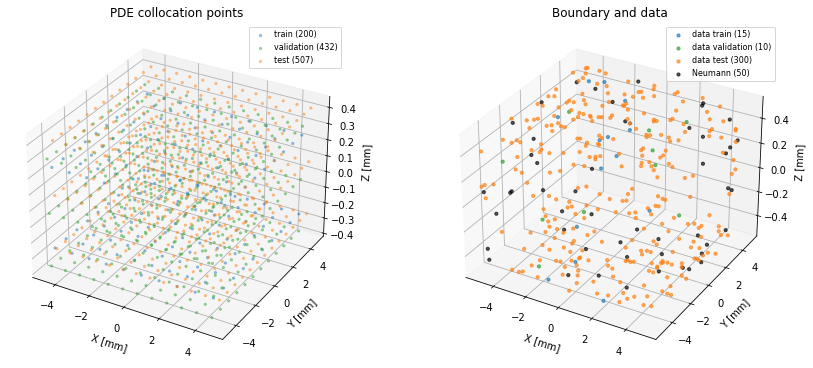

In [42]:
plot_data_split()


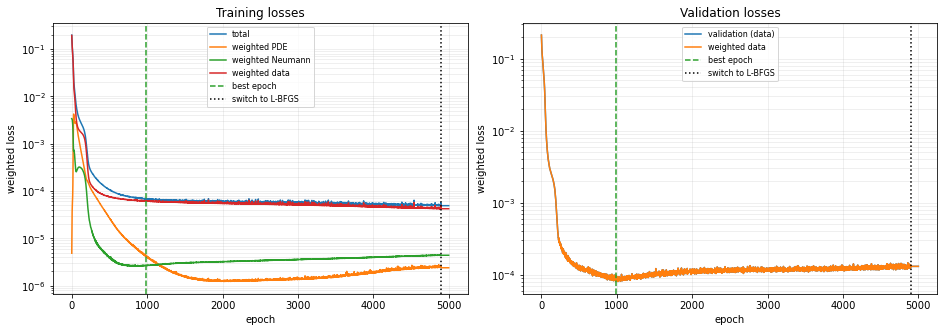

In [43]:
plot_losses()


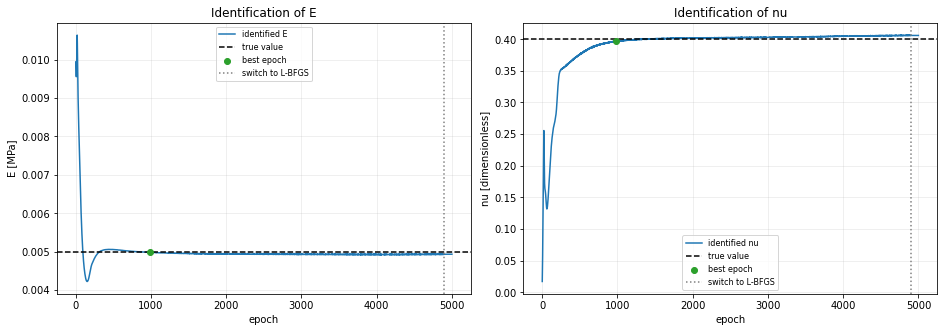

In [44]:
plot_material_parameters()


/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


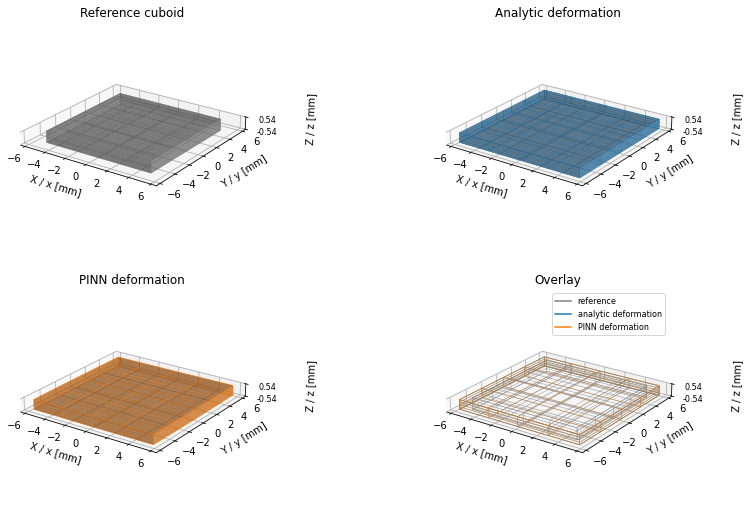

In [45]:
plot_geometry()
